In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.init as init
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import trange
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.style.use('seaborn-whitegrid')
import numpy as np

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda:0")
else:
    device = torch.device("cpu")
print("Device:", device)

Device: cuda:0


### Load MNIST dataset

In [3]:
# Define a transform to normalize the data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Download and load the training data
trainset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=True, transform=transform)
train_loader = DataLoader(trainset, batch_size=64, shuffle=True)

# Download and load the test data
testset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=False, transform=transform)
test_loader = DataLoader(testset, batch_size=64, shuffle=False)

### Build Model

In [4]:
def train_model(model, train_loader, test_loader, loss_fn, optimizer, epochs, device):
    train_errors = []
    test_errors = []
    train_accuracies = []
    test_accuracies = []

    tqdm_epoch = trange(epochs)
    for epoch in tqdm_epoch:
        model.train()
        train_loss = 0.0
        correct_train = 0

        # Training
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            # Forward pass
            outputs = model(batch_X)
            loss = loss_fn(outputs, batch_y)
            
            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * batch_X.size(0)
            # Calculate accuracy
            _, predicted = torch.max(outputs.data, 1)
            correct_train += (predicted == batch_y).sum().item()

        train_loss /= len(train_loader.dataset)
        train_accuracy = 100 * correct_train / len(train_loader.dataset)
        train_errors.append(train_loss)
        train_accuracies.append(train_accuracy)
        
        # Evaluation on test set
        model.eval()
        test_loss = 0.0
        correct_test = 0
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = loss_fn(outputs, batch_y)
                test_loss += loss.item() * batch_X.size(0)
                # Calculate accuracy
                _, predicted = torch.max(outputs.data, 1)
                correct_test += (predicted == batch_y).sum().item()

        test_loss /= len(test_loader.dataset)
        test_accuracy = 100 * correct_test / len(test_loader.dataset)
        test_errors.append(test_loss)
        test_accuracies.append(test_accuracy)

        tqdm_epoch.set_description(f"Epoch {epoch+1}/{epochs} \
            - Train loss: {train_loss:.4f}, Test loss: {test_loss:.4f}, \
            Train Acc: {train_accuracy:.2f}%, Test Acc: {test_accuracy:.2f}%")

    history = dict()
    history['train_loss'] = train_errors
    history['test_loss'] = test_errors
    history['train_acc'] = train_accuracies
    history['test_acc'] = test_accuracies
        
    return history

In [5]:
no_epochs = 20

In [15]:
class FashionMNISTCNN(nn.Module):
    def __init__(self):
        super(FashionMNISTCNN, self).__init__()
        
        # Define the layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3)
        self.fc1 = nn.Linear(64 * 3 * 3, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        # Apply layers and activations
        x = torch.relu(self.conv1(x))
        x = nn.MaxPool2d(2, 2)(x)
        x = torch.relu(self.conv2(x))
        x = nn.MaxPool2d(2, 2)(x)
        x = torch.relu(self.conv3(x))
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

### Categorical Cross Entropy

In [16]:
cce_model = FashionMNISTCNN().to(device)

In [17]:
cce_loss_fn = nn.CrossEntropyLoss()
cce_optimizer = optim.Adam(cce_model.parameters(), lr=0.001)

In [18]:
cce_dict = train_model(cce_model, train_loader, test_loader,
                          cce_loss_fn, cce_optimizer, no_epochs, device)

  0%|          | 0/20 [00:00<?, ?it/s]

### KL Divergence

In [19]:
class KLDivergenceLoss(nn.Module):
    def __init__(self, num_classes):
        super(KLDivergenceLoss, self).__init__()
        self.num_classes = num_classes

    def forward(self, y_pred, y_true):
        # Convert y_true to one-hot encoding
        y_true_one_hot = F.one_hot(y_true, num_classes=self.num_classes).to(torch.float)

        # Apply log_softmax to predictions
        y_pred_log_softmax = F.log_softmax(y_pred, dim=1)

        # Compute KL divergence
        return F.kl_div(y_pred_log_softmax, y_true_one_hot, reduction='batchmean')

In [20]:
kl_model = FashionMNISTCNN().to(device)

In [23]:
num_classes = 10
kl_loss_fn = KLDivergenceLoss(num_classes=num_classes)
kl_optimizer = optim.Adam(kl_model.parameters(), lr=0.001)

In [24]:
kl_dict = train_model(kl_model, train_loader, test_loader,
                      kl_loss_fn, kl_optimizer, no_epochs, device)

  0%|          | 0/20 [00:00<?, ?it/s]

### Plot Training and Validation Accuracy

In [25]:
epochs = range(1, no_epochs + 1)

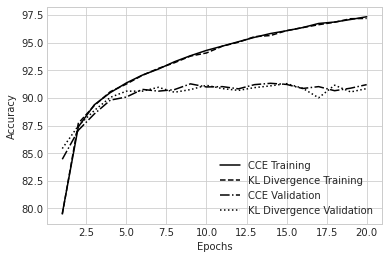

In [26]:
acc_values_cce = cce_dict['train_acc']
acc_values_kl = kl_dict['train_acc']
valacc_values_cce = cce_dict['test_acc']
valacc_values_kl = kl_dict['test_acc']

plt.plot(epochs, acc_values_cce, color='k', linestyle='-', label = 'CCE Training')
plt.plot(epochs, acc_values_kl, color='k', linestyle='--', label = 'KL Divergence Training')
plt.plot(epochs, valacc_values_cce, color='k', linestyle='-.', label = 'CCE Validation')
plt.plot(epochs, valacc_values_kl, color='k', linestyle=':', label = 'KL Divergence Validation')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('TestMNISTLoss.png', dpi=300, bbox_inches='tight')